In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

In [2]:
# ============================================
# LOAD DATASET
# ============================================

df = pd.read_csv("heart.csv")

# Display first 5 rows
print(df.head())

# Dataset Information
print(df.info())

# Check missing values
print(df.isnull().sum())


   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5 

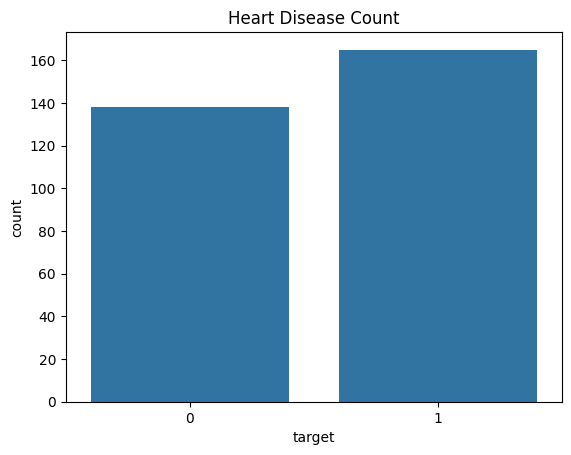

In [4]:
sns.countplot(x='target', data=df)
plt.title("Heart Disease Count")
plt.show()




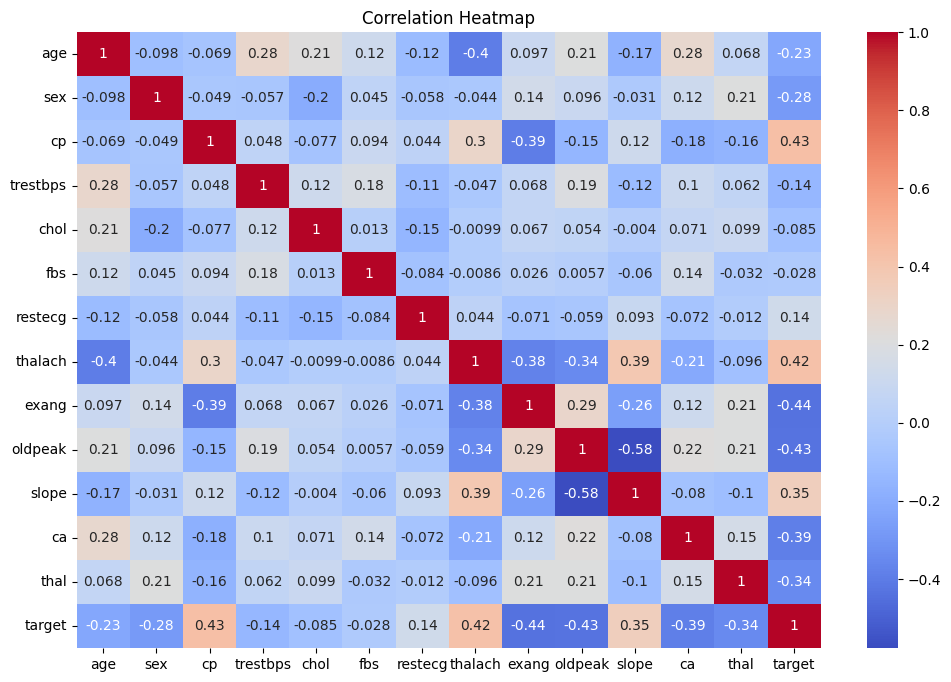

In [5]:
# @title
# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [7]:
# ============================================
# FEATURE SELECTION
# ============================================

X = df.drop('target', axis=1)
y = df['target']

In [8]:
# ============================================
# DATA SPLITTING
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [9]:
# ============================================
# FEATURE SCALING
# ============================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ============================================
# LOGISTIC REGRESSION
# ============================================

lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("\nLOGISTIC REGRESSION")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))


LOGISTIC REGRESSION
Accuracy: 0.8524590163934426
              precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



In [10]:
# ============================================
# DECISION TREE
# ============================================

dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("\nDECISION TREE")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))



DECISION TREE
Accuracy: 0.8524590163934426
              precision    recall  f1-score   support

           0       0.79      0.93      0.86        29
           1       0.93      0.78      0.85        32

    accuracy                           0.85        61
   macro avg       0.86      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61



In [11]:
# ============================================
# RANDOM FOREST
# ============================================

rf_model = RandomForestClassifier(n_estimators=100)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("\nRANDOM FOREST")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))


RANDOM FOREST
Accuracy: 0.8524590163934426
              precision    recall  f1-score   support

           0       0.86      0.83      0.84        29
           1       0.85      0.88      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



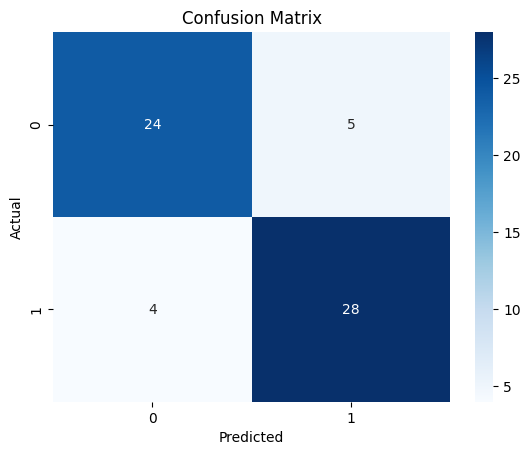

In [12]:
# ============================================
# CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [13]:
# ============================================
# ROC-AUC SCORE
# ============================================

roc_score = roc_auc_score(y_test, rf_pred)

print("ROC-AUC Score:", roc_score)

ROC-AUC Score: 0.8512931034482758


     Feature  Importance
9    oldpeak    0.128533
11        ca    0.121287
7    thalach    0.112471
2         cp    0.110209
0        age    0.093417
12      thal    0.090459
3   trestbps    0.078632
4       chol    0.075523
8      exang    0.069008
10     slope    0.048544
1        sex    0.042355
6    restecg    0.018651
5        fbs    0.010911


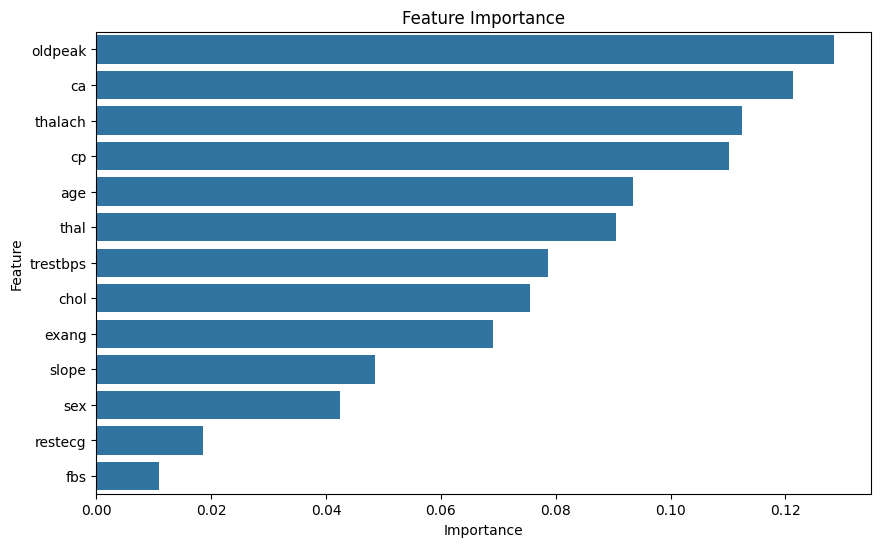

In [14]:
# ============================================
# FEATURE IMPORTANCE
# ============================================

importance = rf_model.feature_importances_

feature_names = X.columns

feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_df = feature_df.sort_values(by='Importance', ascending=False)

print(feature_df)

# Plot Feature Importance
plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_df
)

plt.title("Feature Importance")
plt.show()